# Insurance Cost Analysis

This project analyzes a medical insurance dataset to understand the factors affecting charges and build predictive models.

## Objectives
- Clean and prepare the dataset  
- Perform exploratory data analysis (EDA)  
- Build regression models to predict insurance charges  
- Evaluate and refine model performance  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("medical_insurance_dataset.csv", header=None)

df.head()

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [6]:
df.columns = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


## Data Cleaning

In this step, I clean the dataset by handling missing values and ensuring all columns have the correct data types.

In [7]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

df.isnull().sum()

,0
age,4
sex,0
bmi,0
children,0
smoker,7
region,0
charges,0


Some columns contain non-numeric values such as '?'.
These must be converted to numeric types before handling missing values.

In [11]:
# Convert columns to numeric (force errors to NaN)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce')
df['region'] = pd.to_numeric(df['region'], errors='coerce')

In [12]:
? → NaN

Object ` → NaN` not found.


In [13]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

df['smoker'].fillna(df['smoker'].mode()[0], inplace=True)
df['region'].fillna(df['region'].mode()[0], inplace=True)

/tmp/ipykernel_7721/675811826.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_7721/675811826.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [14]:
df['age'] = df['age'].astype(int)
df['sex'] = df['sex'].astype(int)
df['bmi'] = df['bmi'].astype(float)
df['children'] = df['children'].astype(int)
df['smoker'] = df['smoker'].astype(int)
df['region'] = df['region'].astype(int)
df['charges'] = df['charges'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   int64  
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


## Exploratory Data Analysis (EDA)

In this section, I explore relationships between variables and insurance charges to identify key drivers of cost.

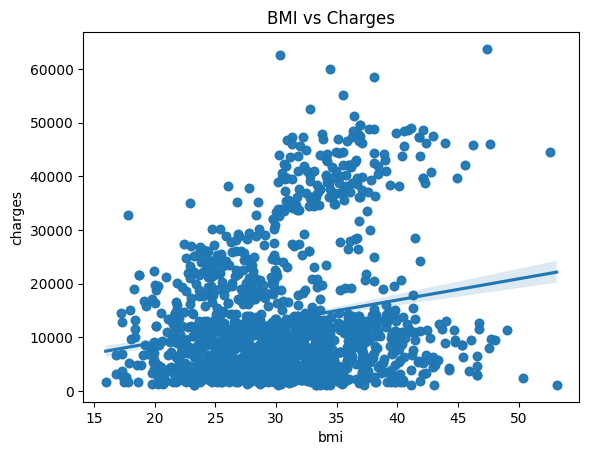

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

This plot shows the relationship between BMI and insurance charges.

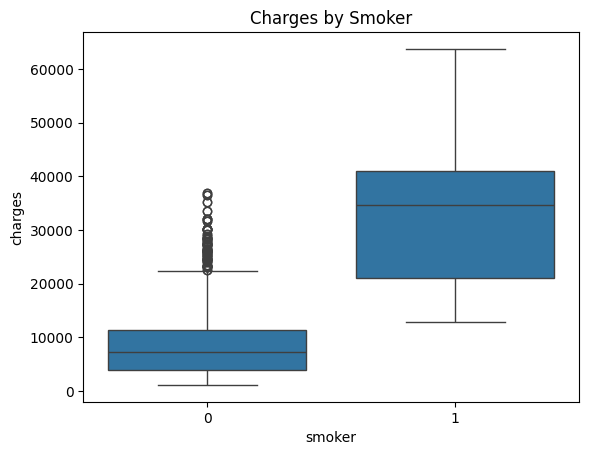

In [16]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker")
plt.show()

This plot compares insurance charges between smokers and non-smokers.

In [17]:
df.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.026046,0.113048,0.037574,-0.023286,-0.007167,0.298624
sex,-0.026046,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113048,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
children,0.037574,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023286,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007167,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298624,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


### Correlation Analysis

The heatmap below visualizes the strength of relationships between numerical variables in the dataset.

### Key Insights from EDA

- **Smoking status is the strongest predictor of insurance charges**  
  The correlation between `smoker` and `charges` (~0.79) is significantly higher than all other variables. This indicates that smokers incur substantially higher medical costs.

- **Age has a moderate positive relationship with charges**  
  Older individuals tend to have higher insurance costs, though the relationship is not as strong as smoking.

- **BMI shows a weak to moderate relationship with charges**  
  Higher BMI is associated with increased charges, but the effect is less pronounced compared to smoking.

- **Number of children and region have minimal impact**  
  These variables show very low correlation with charges, suggesting they are not strong predictors in this dataset.

- **Box plot confirms large cost differences for smokers**  
  The visualization shows a clear separation, with smokers having significantly higher and more variable insurance costs than non-smokers.

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

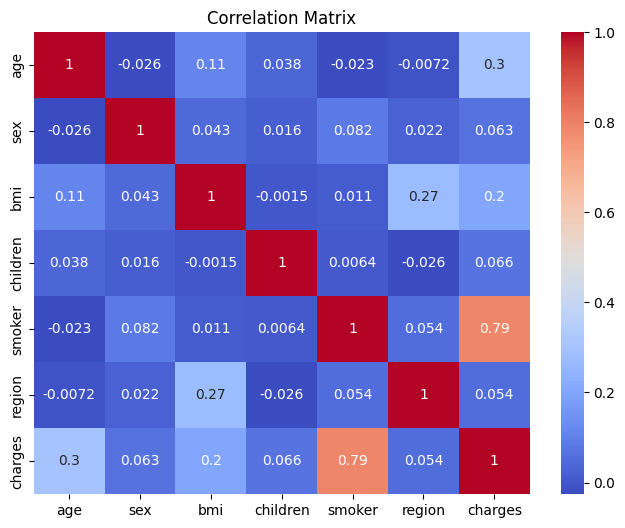

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Model Development

In this section, I build regression models to predict insurance charges and evaluate their performance.

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(df[['bmi']], df['charges'])

print("R² (BMI only):", lr.score(df[['bmi']], df['charges']))

R² (BMI only): 0.03993844319690598


In [19]:
features = ['age', 'bmi', 'children', 'smoker']

lr.fit(df[features], df['charges'])

print("R² (multiple features):", lr.score(df[features], df['charges']))

R² (multiple features): 0.7495508726530692


The simple linear regression model using BMI alone performs poorly (R² ≈ 0.04), indicating that BMI is not a strong standalone predictor of insurance charges.

In contrast, the multiple regression model significantly improves performance (R² ≈ 0.75), demonstrating that insurance costs are influenced by a combination of factors, particularly smoking status, age, and BMI.

This highlights the importance of using multiple features when modeling complex real-world outcomes.

## Model Refinement

In this section, I evaluate model performance using train/test split and apply regularization techniques to improve generalization.

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df[features],
    df['charges'],
    test_size=0.25,
    random_state=1
)

print("Train size:", x_train.shape[0])
print("Test size:", x_test.shape[0])

Train size: 2079
Test size: 693


In [21]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)

ridge.fit(x_train, y_train)

print("Train R²:", ridge.score(x_train, y_train))
print("Test R²:", ridge.score(x_test, y_test))

Train R²: 0.7664838146024404
Test R²: 0.6887712266061641


Ridge regression slightly reduces model performance compared to the standard multiple regression model, but helps improve generalization by penalizing large coefficients.

The smaller gap between training and testing scores indicates reduced overfitting and more stable performance on unseen data.

In [22]:
from sklearn.preprocessing import PolynomialFeatures

pr = PolynomialFeatures(degree=2)

x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

lr.fit(x_train_pr, y_train)

print("Polynomial Train R²:", lr.score(x_train_pr, y_train))
print("Polynomial Test R²:", lr.score(x_test_pr, y_test))

Polynomial Train R²: 0.8554746591944674
Polynomial Test R²: 0.7969159598500968


Polynomial regression significantly improves model performance, achieving a higher R² on both training and testing data.

While the model introduces more complexity, the test score remains strong (R² ≈ 0.80), indicating that the model generalizes well without severe overfitting.

This suggests that incorporating non-linear relationships between features improves the prediction of insurance charges.

## Summary

In this project, I analyzed a medical insurance dataset to understand the factors influencing insurance charges and build predictive models.

### Key Findings
- Smoking status is the strongest predictor of insurance costs
- Age and BMI also contribute to increased charges
- Simple models using a single feature perform poorly
- Combining multiple features significantly improves predictive performance

### Model Insights
- Multiple linear regression improved performance to R² ≈ 0.75
- Ridge regression reduced overfitting and improved model stability
- Polynomial regression achieved the best performance (R² ≈ 0.80 on test data)

### Conclusion
The best-performing model balances complexity and generalization. While more complex models can improve accuracy, evaluating performance on test data is critical to avoid overfitting.

### Tools
Python, Pandas, Scikit-learn, Seaborn, Matplotlib